### This notebook compute "E6. Number of people with water supply for population purposes" indicator for the 27 basins of IKI Project

Spanish: Número de personas con abastecimiento de agua para fines poblacionales 

**Created:** 8/4/2025 by Serena Gilson (sgilson@rti.org)

**Assumptions:** Could only find data at level of Vivienda. Multiplied by average # of people per household: 3.4 members per household (INEI - Peru's National Statistics Institute). Using weighted method to approx. number of people per COMID. 

**N/A Handling:** Zeros are replaced with N/A prior to inserting results to database.  
 
**Notes:** Many zero values but this appears to be reflected in the input data as well. These will be replaced with NaN before inserting the results into the database.  

General Methodology:  
1. Determines proportionate area of each district within each COMID.  
2. Calculates the number of households with water supply per district using INEI data.  
3. Multiplies by 3.4 to estimate population based on average number of people per household.  
4. Applies proportionate values to assign number of people with water supply to COMIDs.  

In [ ]:
import pandas as pd
import numpy as np
import geopandas as gpd
import sqlite3
import matplotlib.pyplot as plt
import yaml
from pathlib import Path

In [ ]:
# set master path for input data from config file

config_path = Path("../../config.yaml")

with open(config_path, "r") as f:
    config = yaml.safe_load(f)

master_path = Path(config["master_path"])

In [ ]:
db_path = master_path / "Indicadores" / "BD_RiesgoClimatico_IKI.db"

# define filepaths for input data
subbasins_shapefile = master_path / "Modelacion" / "Grupos_Modelacion" / "GIS_WaterALLOC_General" / "Peru_AHD_with_districts.shp"

district_area = master_path / "Indicadores" / "COMID_District_Fractions.csv"

inei_path = master_path / "Indicadores" / "Datos_INEI" / "INEI_reporte_E5.xlsx"

In [3]:
# set up indicator ID and get scenarios from database
IndID= 206 #Indicator ID (Exposure = 2 + 0X where X is the Exposure Indicator number, Peligro= 1 +0x, VSB= 3 +0x, VSS= 4 +0x, VCA= 5 +0x)
conn = sqlite3.connect(db_path)

scenarios_df = pd.read_sql_query(
    """
    SELECT ScnID, ScnName
    FROM ScnMod
    """,
    conn
)

conn.close()

# For now: only baseline and first future
scenario_ids = scenarios_df.loc[
    scenarios_df['ScnID'].isin([1, 2]), 'ScnID'
].tolist()

# for all scenarios:
# scenario_ids = scenarios_df['ScnID'].tolist()

In [5]:
#read in input data

#Define District_within_COMID fractions csv - this allows for a weighted method to be used for assigning district level data to subbasins
district_area_within_COMID= pd.read_csv(districts_area)

subbasins_gdf = gpd.read_file(subbasins_shapefile).to_crs('EPSG:32718')

#Read in INEI excel file
INEI_df= pd.read_excel(inei_path)


In [6]:
#WEIGHTED METHOD FUNCTION 
# For each COMID, calculate proportionate lighting values based on district area fractions
#could amplify this fraction so it could read in any value by IDDIST 
def calculate_proportionate_values(district_fractions_df, value_df, column_name, comid_list):
    """
    Calculate proportionate values for each COMID based on district area fractions
    
    Parameters:
    - district_fractions_df: DataFrame with COMID, DISTRICT, district_area_within_COMID_fraction
    - value_df: DataFrame with IDDIST and indicator values
    - column_name: Name of the column containing the indicator values
    - comid_list: List of COMIDs to process
    
    Returns:
    - DataFrame with COMID and proportionate_indicator_value
    """
    # Ensure IDDIST and DISTRICT columns are in the same format
    value_df = value_df.copy()
    district_fractions_df = district_fractions_df.copy()
    
    value_df['IDDIST'] = value_df['IDDIST'].astype(str).str.strip()
    district_fractions_df['DISTRICT'] = district_fractions_df['DISTRICT'].astype(str).str.strip()
    
    results = []
    
    for comid in comid_list:
        # Get all districts within this COMID
        districts_in_comid = district_fractions_df[district_fractions_df['COMID'] == comid]
        
        total_proportionate_value = 0
        
        for _, row in districts_in_comid.iterrows():
            district_id = row['DISTRICT']
            fraction = row['district_area_within_COMID_fraction']
            # Get the indicator value for this district
            ind_value = value_df[value_df['IDDIST'] == district_id][column_name].values

            if len(ind_value) > 0:
                # Multiply district value by the fraction of area within COMID
                proportionate_value = ind_value[0] * fraction
                total_proportionate_value += proportionate_value
        
        results.append({
            'COMID': comid,
            'proportionate_indicator_value': total_proportionate_value
        })
    
    return pd.DataFrame(results)

In [ ]:
# Format INEI dataframe

# Make the fourth row (index 4) the column names
INEI_df.columns = INEI_df.iloc[4]

# Drop the first 4 rows (including the now-duplicate header row)
INEI_df = INEI_df.iloc[5:].reset_index(drop=True)

# Delete any columns named 'NaN' or with NaN as name
INEI_df = INEI_df.loc[:, INEI_df.columns.notna()]
INEI_df = INEI_df.loc[:, ~INEI_df.columns.astype(str).str.contains('nan', case=False)]

# Delete any rows with NaN in Distrito column
INEI_df = INEI_df[INEI_df['Distrito'].notna()]

# Display the cleaned dataframe
print(f"Cleaned INEI_df shape: {INEI_df.shape}")
INEI_df.head()

Cleaned INEI_df shape: (1874, 10)


4,Código,Distrito,Red pública dentro de la vivienda,"Red pública fuera de la vivienda, pero dentro de la edificación",Pilón o pileta de uso público,Camión - cisterna u otro similar,Pozo (agua subterránea),"Río, acequia, lago, laguna",Otro,Vecino
0,10101,"010101 Amazonas, Chachapoyas, distrito: Chacha...",6084,478,56,49,486,30,3,7
1,10102,"010102 Amazonas, Chachapoyas, distrito: Asunción",52,1,0,0,0,0,0,0
2,10103,"010103 Amazonas, Chachapoyas, distrito: Balsas",64,7,1,0,0,0,2,0
3,10104,"010104 Amazonas, Chachapoyas, distrito: Cheto",139,1,0,0,0,2,0,0
4,10105,"010105 Amazonas, Chachapoyas, distrito: Chiliquin",38,22,0,0,0,0,0,0


In [8]:
# Rename Codigo column to IDDIST and create a Total column

# Rename Codigo to IDDIST
INEI_df = INEI_df.rename(columns={'Código': 'IDDIST'})

# Get the index of the Distrito column
distrito_idx = INEI_df.columns.get_loc('Distrito')

# Select all columns to the right of Distrito for summing
columns_to_sum = INEI_df.columns[distrito_idx + 1:]

# Convert these columns to numeric, coercing errors to NaN
for col in columns_to_sum:
    INEI_df[col] = pd.to_numeric(INEI_df[col], errors='coerce')

# Create Total column by summing all numeric columns after Distrito
INEI_df['Total_Households'] = INEI_df[columns_to_sum].sum(axis=1)

# Multiply by 3.4 people per household to get population estimate
INEI_df['Total_Population'] = (INEI_df['Total_Households'] * 3.4).round(2)

# Delete Distrito column as IDDIST has all the information we need
INEI_df = INEI_df.drop(columns=['Distrito'])

print(f"Columns summed: {list(columns_to_sum)}")
print(f"\nINEI_df with Total columns:")
INEI_df[['IDDIST', 'Total_Households', 'Total_Population']].head()

Columns summed: ['Red pública dentro de la vivienda', 'Red pública fuera de la vivienda, pero dentro de la edificación', 'Pilón o pileta de uso público', 'Camión - cisterna u otro similar', 'Pozo (agua subterránea)', 'Río, acequia, lago, laguna', 'Otro', 'Vecino']

INEI_df with Total columns:


4,IDDIST,Total_Households,Total_Population
0,10101,7193,24456.2
1,10102,53,180.2
2,10103,74,251.6
3,10104,142,482.8
4,10105,60,204.0


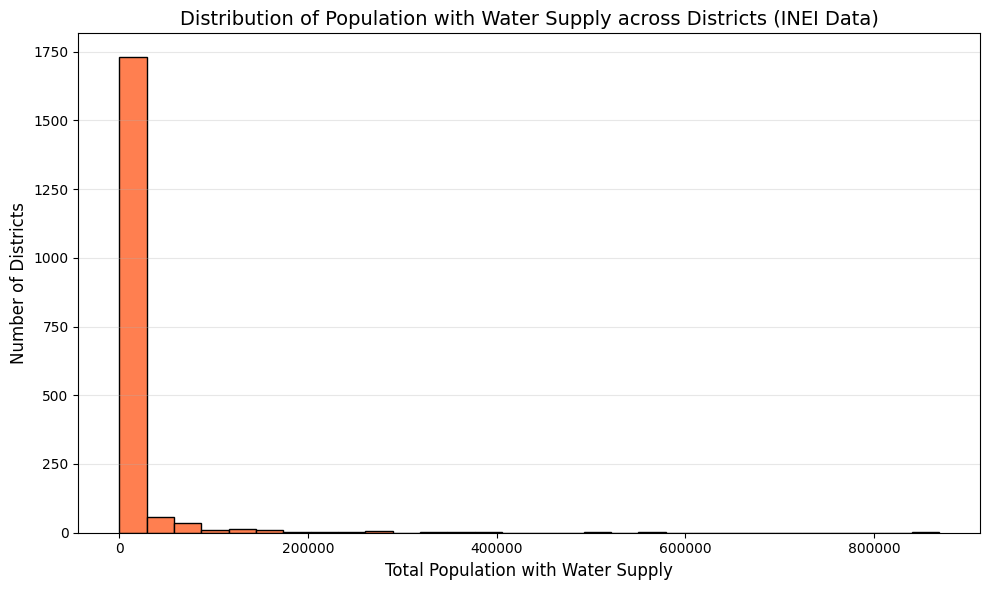


INEI District-Level Statistics:
Mean: 11150.27
Median: 1329.40
Std Dev: 41942.51
Min: 6.80
Max: 868774.80
Total Population: 20895604.40
Number of Districts: 1874


In [9]:
# Create histogram of INEI Total_Population at district level

plt.figure(figsize=(10, 6))
plt.hist(INEI_df['Total_Population'], bins=30, edgecolor='black', color='coral')
plt.xlabel('Total Population with Water Supply', fontsize=12)
plt.ylabel('Number of Districts', fontsize=12)
plt.title('Distribution of Population with Water Supply across Districts (INEI Data)', fontsize=14)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Display summary statistics for district-level data
print("\nINEI District-Level Statistics:")
print(f"Mean: {INEI_df['Total_Population'].mean():.2f}")
print(f"Median: {INEI_df['Total_Population'].median():.2f}")
print(f"Std Dev: {INEI_df['Total_Population'].std():.2f}")
print(f"Min: {INEI_df['Total_Population'].min():.2f}")
print(f"Max: {INEI_df['Total_Population'].max():.2f}")
print(f"Total Population: {INEI_df['Total_Population'].sum():.2f}")
print(f"Number of Districts: {len(INEI_df)}")

In [10]:
# WEIGHTED METHOD: Calculate proportionate population with water supply per COMID

# Get list of all COMIDs
comid_list = subbasins_gdf['COMID'].unique().tolist()

# Calculate proportionate values using weighted method
weighted_results = calculate_proportionate_values(
    district_fractions_df=district_area_within_COMID,
    value_df=INEI_df,
    column_name='Total_Population',
    comid_list=comid_list
)

# Merge weighted results back to subbasins
subbasins_gdf = subbasins_gdf.merge(
    weighted_results,
    on='COMID',
    how='left'
)

# Rename the proportionate value column for clarity
subbasins_gdf = subbasins_gdf.rename(columns={'proportionate_indicator_value': 'Poblacion_Total'})

# Round to 2 decimal places
subbasins_gdf['Poblacion_Total'] = subbasins_gdf['Poblacion_Total'].round(0)

subbasins_gdf.loc[subbasins_gdf['Poblacion_Total'] == 0, 'Poblacion_Total'] = np.nan

print(f"Weighted method applied. Total COMIDs: {len(subbasins_gdf)}")
print(f"\nSummary statistics for Poblacion_Total:")
print(subbasins_gdf['Poblacion_Total'].describe())

Weighted method applied. Total COMIDs: 3655

Summary statistics for Poblacion_Total:
count    3.515000e+03
mean     3.504442e+03
std      4.287313e+04
min      1.000000e+00
25%      5.500000e+01
50%      2.650000e+02
75%      9.210000e+02
max      2.053211e+06
Name: Poblacion_Total, dtype: float64


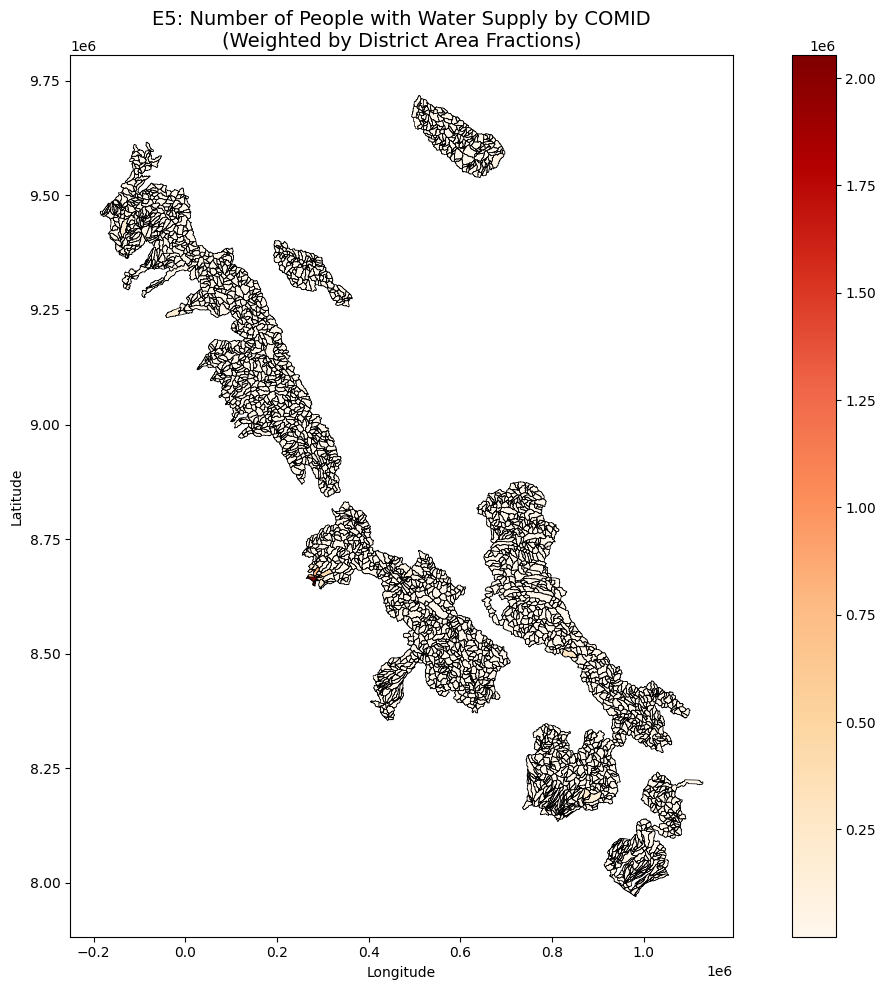

In [11]:
# Plot the population with water supply per COMID
subbasins_gdf.plot(column='Poblacion_Total', cmap='OrRd', legend=True, figsize=(12, 10), edgecolor='black', linewidth=0.5)
plt.title('E5: Number of People with Water Supply by COMID\n(Weighted by District Area Fractions)', fontsize=14)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.show()

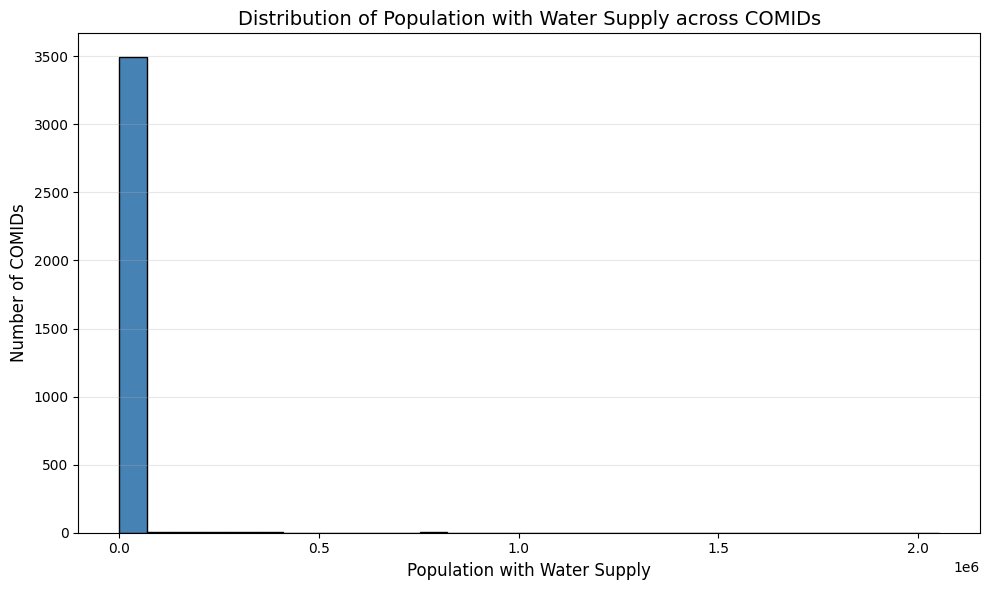


Detailed Statistics:
Mean: 3504.44
Median: 265.00
Std Dev: 42873.13
Min: 1.00
Max: 2053211.00
Total Population: 12318115.00


In [12]:
# Create histogram of results 

plt.figure(figsize=(10, 6))
plt.hist(subbasins_gdf['Poblacion_Total'], bins=30, edgecolor='black', color='steelblue')
plt.xlabel('Population with Water Supply', fontsize=12)
plt.ylabel('Number of COMIDs', fontsize=12)
plt.title('Distribution of Population with Water Supply across COMIDs', fontsize=14)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Display summary statistics
print("\nDetailed Statistics:")
print(f"Mean: {subbasins_gdf['Poblacion_Total'].mean():.2f}")
print(f"Median: {subbasins_gdf['Poblacion_Total'].median():.2f}")
print(f"Std Dev: {subbasins_gdf['Poblacion_Total'].std():.2f}")
print(f"Min: {subbasins_gdf['Poblacion_Total'].min():.2f}")
print(f"Max: {subbasins_gdf['Poblacion_Total'].max():.2f}")
print(f"Total Population: {subbasins_gdf['Poblacion_Total'].sum():.2f}")

SQLITE INSERT 

In [13]:
# insert results into the database 
insert_data= subbasins_gdf #COMID 
value_column= 'Poblacion_Total' #column with calculated values to be inserted into the database

# Connect to your SQLite database
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

# Prepare list of rows to insert
rows_to_insert = []

for scn_id in scenario_ids:
    for _, row in insert_data.iterrows():
        comid = row['COMID']
        value = row[value_column]
        rows_to_insert.append((scn_id, IndID, comid, value))

# Insert data into IndValues_Dyn
insert_query = """
INSERT OR REPLACE INTO IndValues_Dyn (ScnID, IndID, COMID, Value)
VALUES (?, ?, ?, ?);
"""

In [14]:
# check that min and max values match the expected range based on the Indicators Table 
indicator_limits = pd.read_sql_query(
    """
    SELECT IndID, Min, Max
    FROM Indicators
    WHERE IndID = ?
    """,
    conn,
    params=(IndID,)
)

if indicator_limits.empty:
    raise ValueError(f"No entry found in Indicators table for IndID = {IndID}")

ind_min = indicator_limits.loc[0, 'Min']
ind_max = indicator_limits.loc[0, 'Max']

print(f"Indicator {IndID}  Min: {ind_min}, Max: {ind_max}")

value_stats = (
    subbasins_gdf['Poblacion_Total']
    .agg(['min', 'max', 'count'])
    .reset_index()
)

print("\n=== Values to be inserted (by scenario) ===")
print(value_stats)

# check for duplicates 
df_check = pd.DataFrame(rows_to_insert, columns=['ScnID', 'IndID', 'COMID', 'Value'])
duplicates = df_check.duplicated(subset=['ScnID', 'IndID', 'COMID'])
print("Duplicates in rows_to_insert:")
print(df_check[duplicates])

Indicator 206  Min: 0, Max: 10000000

=== Values to be inserted (by scenario) ===
   index  Poblacion_Total
0    min              1.0
1    max        2053211.0
2  count           3515.0
Duplicates in rows_to_insert:
Empty DataFrame
Columns: [ScnID, IndID, COMID, Value]
Index: []


In [15]:
#Execute insert to SQLite Database
cursor.executemany(insert_query, rows_to_insert)
conn.commit()
conn.close()